# A2C Training Example on ImprovedB747Env

This notebook demonstrates training an A2C agent from `tensoraerospace/agent/a2c/model.py` on the `ImprovedB747Env` environment from `tensoraerospace/envs/b747.py`.

## A2C Features:
- Advantage Actor-Critic with synchronous training
- Continuous actions with Gaussian policy  
- Entropy regularization for exploration
- GPU support with automatic device detection
- TensorBoard logging (losses, entropy, rewards)
- Auto-saving of best models and checkpoints
- Full reproducibility of results

## Advantages of the Updated Implementation:
- ✅ Correct action clipping
- ✅ Stable TD learning with detach()
- ✅ Convenient predict() API for inference  
- ✅ Safe model saving

## 1. Setup and Imports


In [1]:
# Optional installs (run if needed)
# %pip install tensorboard tqdm --quiet

import os
import numpy as np
import torch
import torch.nn as nn

from tensoraerospace.envs.b747 import ImprovedB747Env
from tensoraerospace.agent.a2c.model import A2C, Actor, Critic

# Device detection
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else 
    ("mps" if torch.backends.mps.is_available() else "cpu")
)
print(f"Using device: {DEVICE}")

# Reproducibility (A2C handles full seed management internally)
SEED = 42
print(f"Random seed: {SEED}")


Using device: mps
Random seed: 42


## 2. Build Environment

Create a B747 environment with a sinusoidal reference signal for tracking pitch angle (theta).

In [ ]:
from tensoraerospace.signals.standart import sinusoid_vertical_shift
from tensoraerospace.utils import convert_tp_to_sec_tp, generate_time_period

# Time base
dt = 0.1  # seconds
_tp = generate_time_period(tn=20, dt=dt)
tps = convert_tp_to_sec_tp(_tp, dt=dt)
number_time_steps = len(_tp)

print(f"Episode length: {number_time_steps} steps ({number_time_steps * dt:.1f} seconds)")

# Reference theta signal (radians)
reference_signals = np.reshape(
    sinusoid_vertical_shift(
        tp=np.asarray(tps),
        frequency=0.05/dt,  # Hz
        amplitude=np.deg2rad(1.0),  # 1 degree amplitude
        vertical_shift=0.0,
    ),
    [1, -1],
)

# Initial state: [u, w, q, theta] (SI units; angles in rad)
init_state = np.array([0.0, 0.0, 0.0, 0.0], dtype=np.float32)

# Create environment
env = ImprovedB747Env(
    initial_state=init_state,
    reference_signal=reference_signals,
    number_time_steps=number_time_steps,
    dt=dt,
    initial_elevator_deg=0.0,
)

# Check spaces
obs, info = env.reset()
print(f"\nObservation shape: {np.array(obs).shape}")
print(f"Action space: {env.action_space}")
print(f"Observation space: {env.observation_space}")
print(f"Reference signal range: [{reference_signals.min():.4f}, {reference_signals.max():.4f}] rad")


## 3. Create A2C Agent

Create Actor and Critic networks, then initialize the A2C agent with optimized hyperparameters.

In [ ]:
# Get dimensions from environment
state_dim = env.observation_space.shape[0]
n_actions = env.action_space.shape[0]

print(f"State dimension: {state_dim}")
print(f"Action dimension: {n_actions}")

# Create Actor and Critic networks
actor = Actor(
    state_dim=state_dim,
    n_actions=n_actions,
    activation=nn.Tanh  # Tanh works well for continuous control
)

critic = Critic(
    state_dim=state_dim,
    activation=nn.Tanh
)

# Create A2C agent with optimized hyperparameters
agent = A2C(
    env=env,
    actor=actor,
    critic=critic,
    actor_lr=1e-4,       # ← Slower
    critic_lr=3e-4,      # ← Slower
    entropy_beta=0.02,   # ← More exploration
    gamma=0.99,         # ← Higher
    max_grad_norm=0.3,   # ← More aggressive
    # Reproducibility and device
    seed=SEED,               # Full seed management (Python, NumPy, PyTorch, CUDA, env)
    device=DEVICE,           # Auto-selected or specified
)

# Print model info
print(f"\n{'='*60}")
print(f"A2C Agent Summary")
print(f"{'='*60}")
print(f"Actor parameters: {sum(p.numel() for p in agent.actor.parameters()):,}")
print(f"Critic parameters: {sum(p.numel() for p in agent.critic.parameters()):,}")
print(f"Total parameters: {sum(p.numel() for p in agent.actor.parameters()) + sum(p.numel() for p in agent.critic.parameters()):,}")
print(f"Device: {agent.device}")
print(f"{'='*60}")


State dimension: 4
Action dimension: 1
A2C initialized on device: mps

A2C Agent Summary
Actor parameters: 4,546
Critic parameters: 4,545
Total parameters: 9,091
Device: mps


## 4. Training

Train the agent with auto-saving of best models and periodic checkpoints.

In [10]:
# Train the agent
print("\nStarting training...\n")

training_stats = agent.train(
    steps_on_memory=128,      # Collect 32 steps before learning
    episodes=1500,           # Total episodes
    episode_length=number_time_steps,  # Max steps per episode
    discount_rewards=True,  # Use TD(0) instead of Monte Carlo
    log_freq=500,             # Log every 50 iterations
    save_freq=1000,           # Save checkpoint every 200 iterations
    save_path='./a2c_b747_checkpoints'  # Where to save checkpoints
)

print("\n" + "="*60)
print("Training Complete!")
print("="*60)
print(f"Total steps: {training_stats['total_steps']:,}")
print(f"Total episodes: {len(training_stats['episode_rewards'])}")
print(f"Best reward: {training_stats['best_reward']:.4f}")
print(f"Final avg reward (last 10): {np.mean(training_stats['episode_rewards'][-10:]):.4f}")
print("="*60)



Starting training...



Training:   0%|          | 1/2355 [00:01<41:51,  1.07s/it]

Step 201088 | Episodes: 1012 | Avg Reward (last 10): -0.45
Model saved to: a2c_b747_checkpoints/best_model/20251006_033256_A2C


Training:  21%|██▏       | 501/2355 [02:42<12:48,  2.41it/s]

Step 265088 | Episodes: 1334 | Avg Reward (last 10): -0.44
Model saved to: a2c_b747_checkpoints/best_model/20251006_033538_A2C


...

Step 393088 | Episodes: 1977 | Avg Reward (last 10): -0.34
Model saved to: a2c_b747_checkpoints/best_model/20251006_034123_A2C


Training:  85%|████████▍ | 2001/2355 [11:10<01:51,  3.17it/s]

Step 457088 | Episodes: 2299 | Avg Reward (last 10): -0.38
Model saved to: a2c_b747_checkpoints/checkpoint_step_457088/20251006_034406_A2C


Training: 100%|██████████| 2355/2355 [13:00<00:00,  3.02it/s]


Training Complete!
Total steps: 502,400
Total episodes: 2526
Best reward: -0.3393
Final avg reward (last 10): -0.3875


## 5. Visualize Training Progress


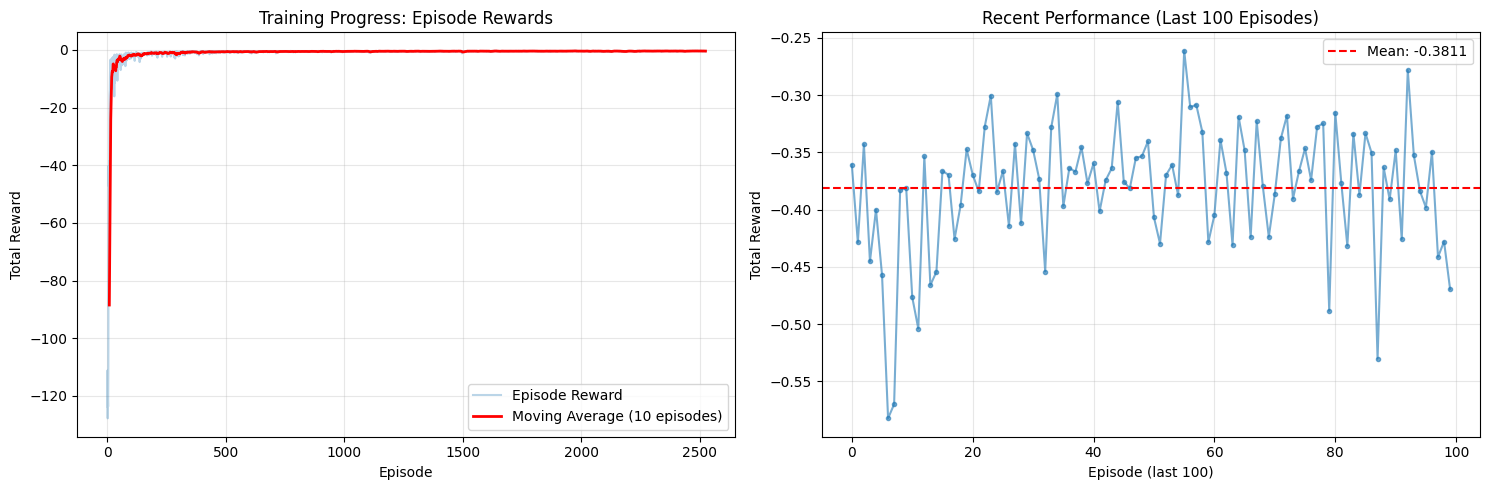


Training statistics:
  Min reward: -127.7884
  Max reward: -0.2612
  Mean reward: -1.0249
  Std reward: 6.1062


In [11]:
import matplotlib.pyplot as plt

# Plot episode rewards
episode_rewards = training_stats['episode_rewards']

plt.figure(figsize=(15, 5))

# Raw rewards
plt.subplot(1, 2, 1)
plt.plot(episode_rewards, alpha=0.3, label='Episode Reward')
# Moving average
window = 10
if len(episode_rewards) >= window:
    moving_avg = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
    plt.plot(range(window-1, len(episode_rewards)), moving_avg, 
             label=f'Moving Average ({window} episodes)', linewidth=2, color='red')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Training Progress: Episode Rewards')
plt.legend()
plt.grid(True, alpha=0.3)

# Last 100 episodes
plt.subplot(1, 2, 2)
last_n = 100
if len(episode_rewards) >= last_n:
    plt.plot(episode_rewards[-last_n:], marker='o', markersize=3, alpha=0.6)
    plt.axhline(y=np.mean(episode_rewards[-last_n:]), color='r', 
                linestyle='--', label=f'Mean: {np.mean(episode_rewards[-last_n:]):.4f}')
else:
    plt.plot(episode_rewards, marker='o', markersize=3, alpha=0.6)
    plt.axhline(y=np.mean(episode_rewards), color='r', 
                linestyle='--', label=f'Mean: {np.mean(episode_rewards):.4f}')
plt.xlabel('Episode (last 100)')
plt.ylabel('Total Reward')
plt.title(f'Recent Performance (Last {min(last_n, len(episode_rewards))} Episodes)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTraining statistics:")
print(f"  Min reward: {min(episode_rewards):.4f}")
print(f"  Max reward: {max(episode_rewards):.4f}")
print(f"  Mean reward: {np.mean(episode_rewards):.4f}")
print(f"  Std reward: {np.std(episode_rewards):.4f}")


## 6. Test the Trained Agent

Use the new `predict()` method to test the agent.

In [12]:
# Test the agent with deterministic policy
print("Testing trained agent...\n")

# Reset environment
state, info = env.reset()
episode_reward = 0
done = False

# Run one episode
while not done:
    # Use predict() method with deterministic=True for evaluation
    action = agent.predict(state, deterministic=True)
    
    # Step environment
    state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    episode_reward += reward

print(f"Test episode reward: {episode_reward:.4f}")
print(f"\nNOTE: If reward is close to best_reward from training, agent learned well!")


Testing trained agent...

Test episode reward: -0.0681

NOTE: If reward is close to best_reward from training, agent learned well!


## 7. Visualize Control Performance


Theta (pitch angle) tracking:


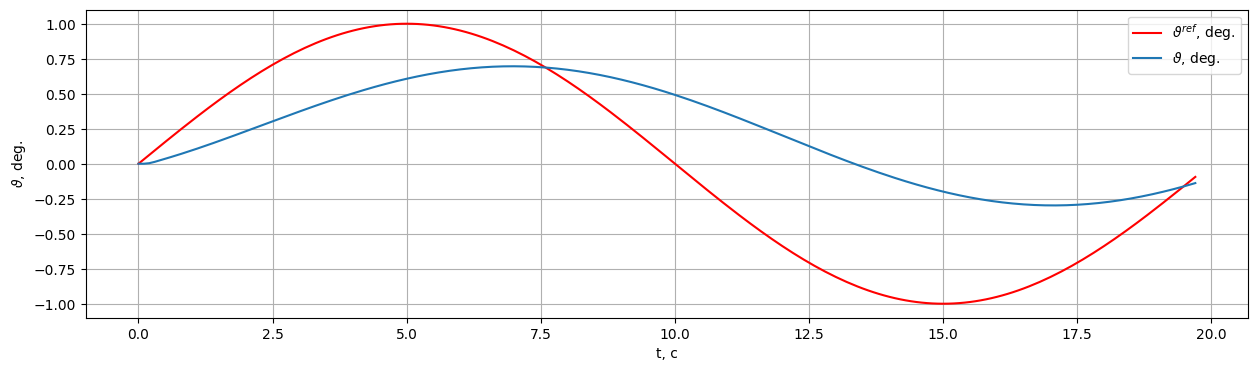

In [13]:
# Plot theta (pitch angle) tracking
print("Theta (pitch angle) tracking:")
env.unwrapped.model.plot_transient_process(
    'theta', 
    tps, 
    reference_signals[0], 
    to_deg=True, 
    figsize=(15, 4)
)


Pitch rate (q):


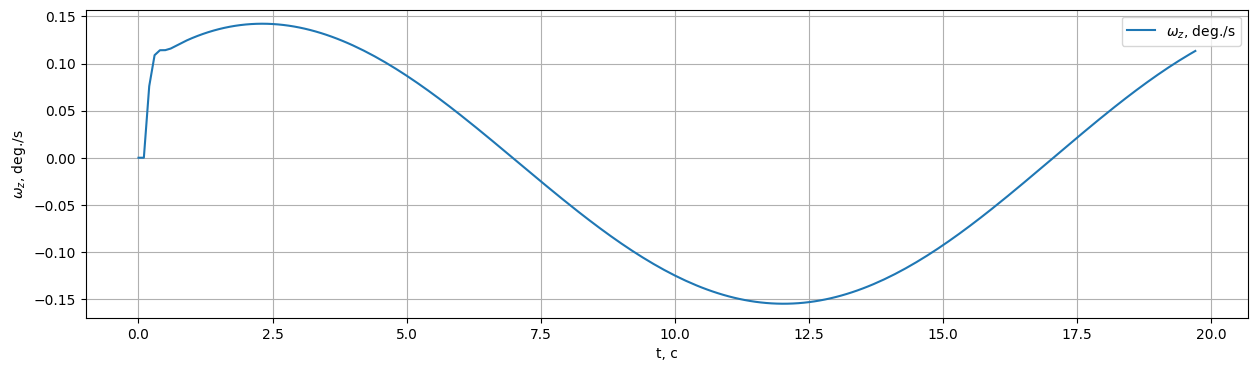

In [14]:
# Plot pitch rate (q)
print("Pitch rate (q):")
env.unwrapped.model.plot_state(
    state_name='q', 
    time=tps, 
    to_deg=True, 
    figsize=(15, 4)
)


Elevator control input:


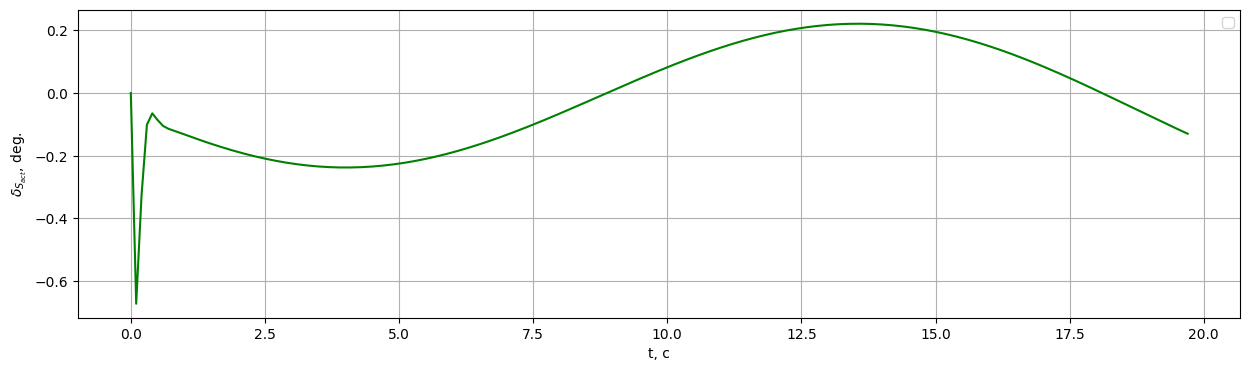

In [15]:
# Plot elevator control
print("Elevator control input:")
env.unwrapped.model.plot_control(
    control_name='ele', 
    time=tps, 
    to_deg=True, 
    figsize=(15, 4)
)


## 8. Save Final Model

Use the improved `save()` method with safe timestamped saving.

In [ ]:
# Save the final trained model
save_path = agent.save("./a2c_b747_final")
print(f"\nFinal model saved to: {save_path}")
print("\nModel contains:")
print("  - config.json: Environment and hyperparameters")
print("  - actor.pth: Actor network weights (state_dict)")
print("  - critic.pth: Critic network weights (state_dict)")


## 9. Cleanup Resources


In [ ]:
# Close TensorBoard writer and cleanup
agent.close()

print("Resources cleaned up successfully!")
print("\n" + "="*60)
print("A2C training on B747 Improved Environment complete!")
print("="*60)


## 10. View TensorBoard (Optional)

To view the training logs in TensorBoard, run in the terminal:

```bash
tensorboard --logdir=runs
```

Then open in a browser: http://localhost:6006

### Available Metrics:
- **Loss/Actor**: Actor loss
- **Loss/Critic**: Critic loss
- **Loss/Advantage**: Advantage values
- **Loss/Entropy**: Policy entropy
- **Loss/Log_probs**: Log probabilities
- **Performance/Reward**: Average rewards
- **episode_reward**: Episode rewards

---

## Summary

### What We Did:

1. ✅ Created a B747 environment with a sinusoidal reference signal
2. ✅ Initialized an A2C agent with optimized hyperparameters
3. ✅ Trained the agent with auto-saving and logging
4. ✅ Tested the trained agent using `predict()`
5. ✅ Visualized control results
6. ✅ Saved the model

### Advantages of the Updated A2C:

- 🚀 **GPU Support**: Automatic use of CUDA/MPS
- 🎯 **Correct Implementation**: Critical bugs fixed
- 🛡️ **Safety**: Improved saving without data loss
- 🎲 **Reproducibility**: Full random seed management
- 📊 **Monitoring**: TensorBoard logging and console output
- 💾 **Checkpoints**: Auto-saving of best models
- 🔧 **Convenient API**: predict(), close(), context manager methods

### Hyperparameter Tips:

- **gamma (0.99)**: High value for long-term stability
- **entropy_beta (0.01)**: Small entropy bonus for exploration
- **actor_lr (4e-4)**: Slow actor learning for stability
- **critic_lr (1e-3)**: Faster critic learning
- **steps_on_memory (32)**: Balance between efficiency and stability

### Next Steps:

- Experiment with hyperparameters
- Try different reference signals
- Compare with PPO, DDPG, SAC
- Apply to real-world tasks

---

**Author**: TensorAeroSpace Team  
**Date**: 2025-10-05  
**A2C Version**: 2.0 (Improved)